### Scaling notebook C: identify LFEs of interest

In [45]:
import numpy as np
import os
import matplotlib.pyplot as plt

import os,sys
sys.path.append(os.path.join(os.environ['PYFILES']))
import LFEAnalysis as lfeanalysis
lfeanalysis.reload_all(lfeanalysis)

### 1. Load the detections

In [46]:
lf=lfeanalysis.lfeanalyse(fnum=156,region='Cascadia',catalog='Bostock',data_directory=None)

# read detection and templates
lf.read_detection_info()

### 2. Identify families with plenty of detections

In [47]:
# note the number of events per LFE
nper=np.bincount(lf.fnums)
fnums=np.where(nper>0)[0]
nper=nper[fnums]

print('
for k in range(0,len(fnums)):
    print('Family {:d}: {:d}'.format(fnums[k],nper[k]))

SyntaxError: unterminated string literal (detected at line 6) (3842038835.py, line 6)

In [48]:
# families we've already downloaded
fhave=np.array([74,246,66,23,144,70,65,156,61,23,55,3,7,49,142,31,256,12,70,53,22,30,52,62,191,1],dtype=int)

# those we might want to get
fget=np.array(list(set(fnums)-set(fhave)))

print('We have data for {:d} LFE families; {:d} more are available.'.format(fhave.size,fget.size))

We have data for 26 LFE families; 65 more are available.


In [49]:
# pick some LFEs to download data for
fdownload=np.random.choice(fget,1,replace=False)
print('Getting data for {:d} LFEs:'.format(fdownload.size),fdownload)

Getting data for 1 LFEs: [250]


### 3. Download the data

In [50]:
# specify a pre-filter and a water level
# these will be applied in the response correction
pre_filt=(1/15.,1/5.,30,40)
water_level=100.

In [ ]:
for fnum in fdownload:
    # initialize data and detections
    lf=lfeanalysis.lfeanalyse(fnum=fnum,data_directory=None,region='Cascadia',catalog='Bostock')
    lf.read_detection_info()

    print('We are analysing LFE family {:d} in {:s}'.format(lf.fnum,lf.region))
    
    # Bostock et al (2015) and Royer et al (2015) already made stacks of LFEs: templates,
    # let's identify the arrival times and compute the signal to noise power ratios in those stacks
    # choose a minimum power ratio of 10
    lf.pick_templates(wlen=5,minsnr=10.)


    # the signal to noise power ratios are saved in a dictionary
    print('{:d} stations have good SNR in the templates, with power SNR of'.format(len(lf.stns)))
    print(', '.join(['{:0.1f}'.format(lf.temp_snrs[stn]) for stn in lf.stns]))

    # identify the channels to download
    lf.identify_channels()

    # delete everything in the data directory.
    lf.clear_seismic_data()
    
    # download the data 
    lf.download_data(max_events=float('inf'),pre_filt=pre_filt,water_level=water_level)


We are analysing LFE family 250 in Cascadia
6 stations have good SNR in the templates, with power SNR
12.7, 27.6, 14.2, 28.6, 38.3, 56.9
Identified channels for 6 of 6 stations
No data?


In [52]:
# to read in data and check
lf2=lfeanalysis.lfeanalyse(fnum=fnum,data_directory=None,region='Cascadia',catalog='Bostock')
lf2.read_detection_info()
lf2.read_data()

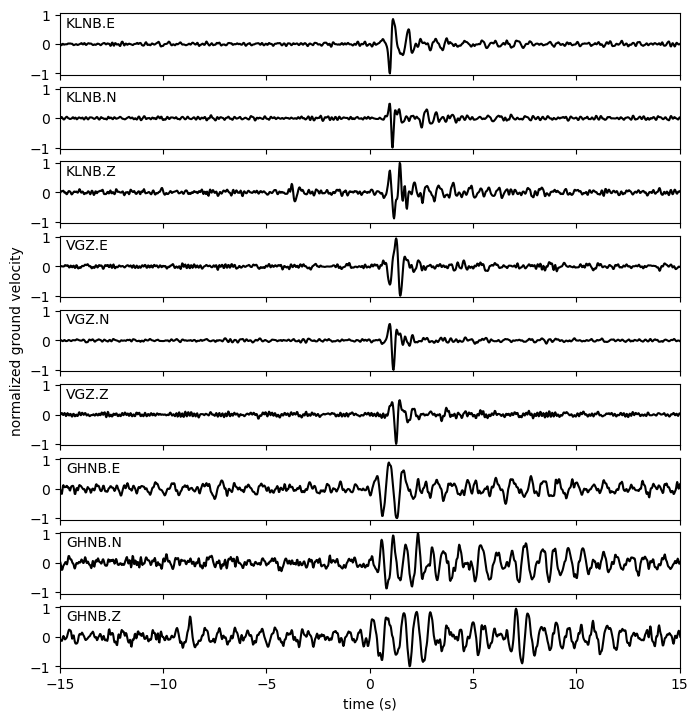

In [40]:
lf.plot_stacks(stype='template',stn=np.random.choice(lf.stns,3));